## ANNNI Model Run on IBM's Noisy Model

In [ ]:
import os, time
import numpy as np
from qiskit.circuit.library import EfficientSU2
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke
from qiskit_ibm_runtime import EstimatorV2 as Estimator

In [ ]:
import os
os.chdir(r"C:\qiskit-project")
print([f for f in os.listdir() if f.endswith(".npz")])

In [ ]:
def build_annni_ham(N, J1, J2, h, bc="periodic"):
    sl = []
    for i in range(N - 1): sl.append(("ZZ", [i, i + 1], -J1))
    if bc == "periodic": sl.append(("ZZ", [N - 1, 0], -J1))
    for i in range(N - 2): sl.append(("ZZ", [i, i + 2], J2))
    if bc == "periodic":
        sl.append(("ZZ", [N - 2, 0], J2)); sl.append(("ZZ", [N - 1, 1], J2))
    for i in range(N): sl.append(("X", [i], h))
    return SparsePauliOp.from_sparse_list(sl, num_qubits=N)
 
 
def build_HA(N, bc="periodic"):
    sl = []
    for i in range(N - 2): sl.append(("ZZ", [i, i + 2], 1.0))
    if bc == "periodic":
        sl.append(("ZZ", [N - 2, 0], 1.0)); sl.append(("ZZ", [N - 1, 1], 1.0))
    return SparsePauliOp.from_sparse_list(sl, num_qubits=N)
 
 
def build_ansatz(N, bc="periodic", reps=2):
    r1 = [[i, i + 1] for i in range(0, N - 1, 2)]
    r2 = [[i, i + 1] for i in range(1, N - 1, 2)]
    if bc == "periodic": r2 = r2 + [[N - 1, 0]]
    return EfficientSU2(num_qubits=N, su2_gates=["ry", "rz"], entanglement=r1 + r2, reps=reps)

In [ ]:
N, J1, h, BC, REPS = 12, 1.0, 0.1, "periodic", 2
SHOTS = 4096
POINTS_PER_CALL = 3   # process this many, checkpoint, stop  call again to continue
 
IDEAL_FILE = "annni_N12_h0.1_periodic_reps2_ideal.npz"  # your already-generated data , no separate file
CKPT = "annni_fakesherbrooke_checkpoint.npz"
FINAL = f"annni_N{N}_h{h}_{BC}_reps{REPS}_noisy.npz"
 
sim = np.load(IDEAL_FILE)
sim_j2, sim_params = sim["j2"], sim["params"]
sim_E, sim_Eexact = sim["energy_vqe"], sim["energy_exact"]
sim_dE, sim_dEexact = sim["denergy_dj2_vqe"], sim["denergy_dj2_exact"]
 
ansatz = build_ansatz(N, bc=BC, reps=REPS)
backend = FakeSherbrooke()
pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
estimator = Estimator(mode=backend)
estimator.options.default_shots = SHOTS

In [ ]:
if os.path.exists(CKPT):
    ck = np.load(CKPT)
    done_E, done_dE = list(ck["energy_noisy"]), list(ck["denergy_dj2_noisy"])
    start_idx = len(done_E)
    print(f"Resuming: {start_idx}/{len(sim_j2)} points already done.")
else:
    done_E, done_dE = [], []
    start_idx = 0
    print("Starting fresh.")
 
end_idx = min(start_idx + POINTS_PER_CALL, len(sim_j2))
for k in range(start_idx, end_idx):
    J2 = float(sim_j2[k])
    t0 = time.time()
 
    bound_circuit = ansatz.assign_parameters(sim_params[k])
    isa_circuit = pm.run(bound_circuit)
    isa_H = build_annni_ham(N, J1, J2, h, BC).apply_layout(isa_circuit.layout)
    isa_HA = build_HA(N, BC).apply_layout(isa_circuit.layout)
 
    job = estimator.run([(isa_circuit, [isa_H, isa_HA])])
    e, de = job.result()[0].data.evs
    dt = time.time() - t0
 
    done_E.append(float(e))
    done_dE.append(float(de))
 
    print(f"[{k+1:2d}/{len(sim_j2)}] J2/J1={J2:.3f} | noisy E={e:.4f} "
          f"(ideal {sim_E[k]:.4f}, exact {sim_Eexact[k]:.4f}) | "
          f"noisy dE/dJ2={de:.4f} (ideal {sim_dE[k]:.4f}, exact {sim_dEexact[k]:.4f}) | {dt:.1f}s")
 
    np.savez(CKPT, energy_noisy=np.array(done_E), denergy_dj2_noisy=np.array(done_dE))
 
print(f"\nCheckpoint now has {len(done_E)}/{len(sim_j2)} points.")
if len(done_E) >= len(sim_j2):
    np.savez(FINAL, j2=sim_j2, energy_noisy=np.array(done_E), denergy_dj2_noisy=np.array(done_dE),
              energy_vqe_ideal=sim_E, energy_exact=sim_Eexact,
              denergy_dj2_ideal=sim_dE, denergy_dj2_exact=sim_dEexact,
              backend_name=backend.name, shots=SHOTS)
    print(f"DONE. Full 21 - point noisy comparison written to {FINAL}")
else:
    print("Not done yet run this script again to continue from checkpoint.")

saved annni_three_way_comparison.png
mean |Noisy-Ideal| energy gap: 0.8620
mean |Noisy-Exact| energy gap:  0.9161
sign(dE_noisy) == sign(dE_ideal): 21/21 points


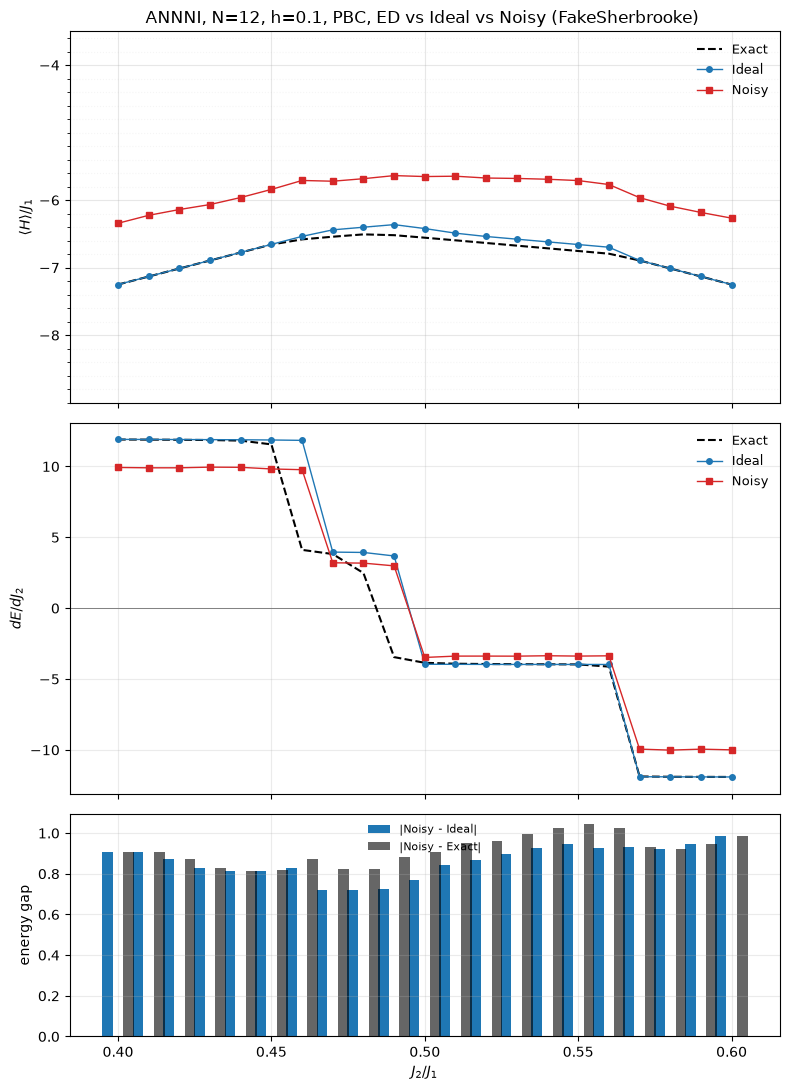

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, FixedLocator

d = np.load("annni_N12_h0.1_periodic_reps2_noisy.npz")

j2 = d["j2"]
E_ideal, E_exact, E_noisy = d["energy_vqe_ideal"], d["energy_exact"], d["energy_noisy"]
dE_ideal, dE_exact, dE_noisy = d["denergy_dj2_ideal"], d["denergy_dj2_exact"], d["denergy_dj2_noisy"]
backend_name = str(d["backend_name"])

fig, axes = plt.subplots(3, 1, figsize=(8, 11), sharex=True,
                          gridspec_kw={"height_ratios": [2, 2, 1.2]})

# Panel 1: energy, all three series 
ax = axes[0]
ax.plot(j2, E_exact, "k--", lw=1.5, label="Exact")
ax.plot(j2, E_ideal, "o-", color="#1f77b4", ms=4, lw=1, label="Ideal")
ax.plot(j2, E_noisy, "s-", color="#d62728", ms=4, lw=1, label=f"Noisy")
ax.set_ylabel(r"$\langle H \rangle / J_1$")
ax.set_title(f"ANNNI, N=12, h=0.1, PBC, ED vs Ideal vs Noisy (FakeSherbrooke) ")
ax.legend(frameon=False, fontsize=9)
ax.yaxis.set_major_locator(FixedLocator([-8, -7, -6, -4]))
ax.yaxis.set_minor_locator(AutoMinorLocator(5))  
ax.set_ylim(-9.0, -3.5)
ax.grid(which="major", alpha=0.3)
ax.grid(which="minor", alpha=0.12, linestyle=":")

# Panel 2: derivative, all three series 
ax = axes[1]
ax.axhline(0, color="grey", lw=0.7)
ax.plot(j2, dE_exact, "k--", lw=1.5, label="Exact")
ax.plot(j2, dE_ideal, "o-", color="#1f77b4", ms=4, lw=1, label="Ideal")
ax.plot(j2, dE_noisy, "s-", color="#d62728", ms=4, lw=1, label=f"Noisy")
ax.set_ylabel(r"$dE/dJ_2$")
ax.legend(frameon=False, fontsize=9)
ax.grid(alpha=0.25)

#  Panel 3: how far noisy sits from each reference, point by point 
ax = axes[2]
width = 0.0035
ax.bar(j2 - width, np.abs(E_noisy - E_ideal), width=width * 1, color="#1f77b4", label="|Noisy - Ideal|")
ax.bar(j2 + width, np.abs(E_noisy - E_exact), width=width * 1, color="#000000", alpha=0.6, label="|Noisy - Exact|")
ax.set_ylabel("energy gap")
ax.set_xlabel(r"$J_2/J_1$")
ax.legend(frameon=False, fontsize=8)
ax.grid(alpha=0.25)

fig.tight_layout()
fig.savefig("annni_three_way_comparison.png", dpi=150)
print("saved annni_three_way_comparison.png")
print(f"mean |Noisy-Ideal| energy gap: {np.mean(np.abs(E_noisy-E_ideal)):.4f}")
print(f"mean |Noisy-Exact| energy gap:  {np.mean(np.abs(E_noisy-E_exact)):.4f}")
print(f"sign(dE_noisy) == sign(dE_ideal): {np.sum(np.sign(dE_noisy)==np.sign(dE_ideal))}/{len(j2)} points")